In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../../Data/top100_ai_tools_2026.csv")
df

,Rank,Tool_Name,Primary_Category,Sub_Category,Pricing_Model,Starting_Price_USD,Monthly_Traffic_Est,User_Rating,Agentic_Capability_Score,API_Available,Release_Year,Active_Users_Est,Description
0,1,ChatGPT,Conversational AI,General Assistant,Freemium,20.00,1800000000,4.80,9.50,Yes,2022,180000000,"OpenAI's flagship conversational AI for text, ..."
1,2,Gemini,Conversational AI,Multimodal AI,Freemium,19.99,500000000,4.70,9.30,Yes,2023,90000000,Google's multimodal AI integrated with Google ...
2,3,Canva AI,Image Generation,Design Assistant,Freemium,15.00,500000000,4.60,6.00,Yes,2023,170000000,AI design tools integrated in Canva
3,4,Character.AI,Conversational AI,Roleplay & Chat,Freemium,9.99,300000000,4.30,6.00,No,2022,20000000,AI characters for entertainment and roleplay
4,5,Claude,Conversational AI,General Assistant,Freemium,20.00,200000000,4.80,9.40,Yes,2023,50000000,Anthropic's safety-focused AI assistant with l...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,Koral Bot,Research & Search,Market Research,Paid,196.25,114463,4.10,6.08,No,2023,38201,AI research assistant for faster knowledge dis...
496,497,Quill Flow,HR & Recruiting,Employee Onboarding,Paid,71.45,101182,4.18,7.39,Yes,2023,3464,AI recruitment and HR automation platform
497,498,Cipher GPT,Legal AI,Legal Research,Paid,414.84,88779,4.38,7.20,Yes,2023,18600,"AI platform for legal research, drafting, and ..."
498,499,Quill GPT,HR & Recruiting,Employee Onboarding,Paid,84.36,80270,4.22,7.35,Yes,2021,14974,AI recruitment and HR automation platform


In [3]:
num = ['Starting_Price_USD', 'Monthly_Traffic_Est', 'User_Rating', 'Agentic_Capability_Score', 'Active_Users_Est']

cat = ['Primary_Category','Pricing_Model', 'API_Available', 'Release_Year']

In [6]:
df_numerical = df[num]
df_numerical

,Starting_Price_USD,Monthly_Traffic_Est,User_Rating,Agentic_Capability_Score,Active_Users_Est
0,20.00,1800000000,4.80,9.50,180000000
1,19.99,500000000,4.70,9.30,90000000
2,15.00,500000000,4.60,6.00,170000000
3,9.99,300000000,4.30,6.00,20000000
4,20.00,200000000,4.80,9.40,50000000
...,...,...,...,...,...
495,196.25,114463,4.10,6.08,38201
496,71.45,101182,4.18,7.39,3464
497,414.84,88779,4.38,7.20,18600
498,84.36,80270,4.22,7.35,14974


In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_numerical.drop("User_Rating", axis=1), df_numerical['User_Rating'])

In [8]:
X_train.describe()

,Starting_Price_USD,Monthly_Traffic_Est,Agentic_Capability_Score,Active_Users_Est
count,375.000000,3.750000e+02,375.000000,3.750000e+02
mean,59.332560,1.361242e+07,6.593493,2.101439e+06
std,94.094817,1.019749e+08,1.485684,1.411026e+07
min,0.000000,6.587800e+04,2.000000,3.510000e+02
25%,12.250000,6.558280e+05,5.600000,3.289200e+04
50%,23.990000,1.260272e+06,6.620000,9.845300e+04
75%,69.645000,3.000000e+06,7.585000,2.625430e+05
max,1000.000000,1.800000e+09,9.940000,1.800000e+08


# Standard Scaller

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scalled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scalled = pd.DataFrame(scaler.fit_transform(X_test), columns=X_test.columns)

In [13]:
X_train_scalled

,Starting_Price_USD,Monthly_Traffic_Est,Agentic_Capability_Score,Active_Users_Est
0,-0.323963,-0.116052,-0.716784,-0.139559
1,-0.469010,-0.115495,-1.073998,-0.144615
2,-0.546270,-0.055111,-0.737003,-0.042681
3,-0.450494,0.357306,-0.400008,0.560522
4,-0.418568,-0.035472,-0.400008,-0.113646
...,...,...,...,...
370,-0.249258,-0.109042,-0.918981,-0.142939
371,-0.546270,-0.104208,-0.400008,-0.142032
372,-0.517750,-0.128743,-0.009094,-0.126667
373,0.330293,-0.123980,-0.184332,-0.147511


In [14]:
X_train.columns

Index(['Starting_Price_USD', 'Monthly_Traffic_Est', 'Agentic_Capability_Score',
       'Active_Users_Est'],
      dtype='str')

# Effect of scalling

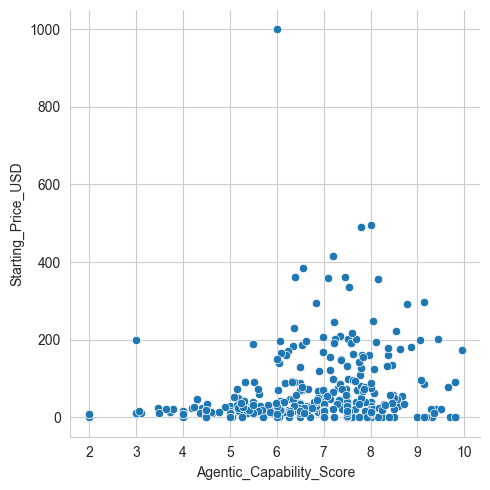

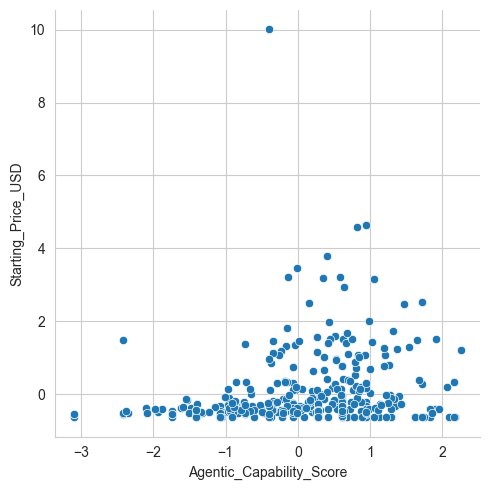

In [15]:
sns.relplot(data=X_train,x='Agentic_Capability_Score',y="Starting_Price_USD")
sns.relplot(data=X_train_scalled,x='Agentic_Capability_Score',y="Starting_Price_USD")

# Comparison of distribution

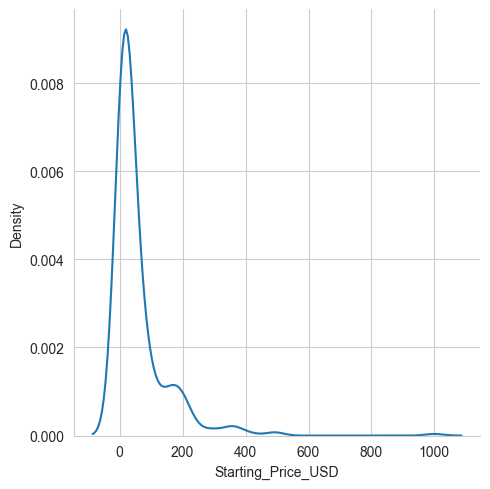

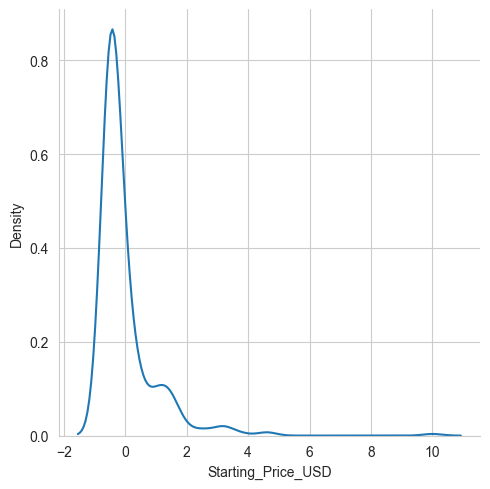

In [17]:
sns.displot(kind='kde',data=X_train,x='Starting_Price_USD')
sns.displot(kind='kde',data=X_train_scalled,x='Starting_Price_USD')